In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import datasets
from sklearn.model_selection import train_test_split
import torch
import gbtoolbox.bounds as bounds
import gbtoolbox.misc as mt
import gbtoolbox.dft as dft
import gbtoolbox.nn as gbnn
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
import torch.nn.functional as F
import cupy as cp
import matplotlib.colors as colors
import time
import seaborn as sns
import pandas as pd

We use additional libraries for this example.

In [2]:
import numba
from numba import jit
from numba.experimental import jitclass
@jit(nopython=True)
def rmse(y1, y2):
    return np.sqrt(((y1-y2)*np.conj(y1-y2)).mean())

In [3]:
digits = datasets.load_digits()
print(digits.DESCR)
print(digits.data.shape)
print(digits.images.shape)
print(digits.target.shape)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

The Digits dataset is similar to MNIST but simplified. Thus it makes a good test case for a computer vision problem.

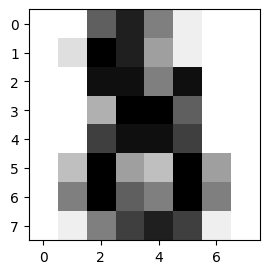

In [4]:
plt.figure(1, figsize=(3, 3))
plt.imshow(digits.images[-1], cmap=plt.cm.gray_r)
plt.show()

In [5]:
num_features = 6
pca = PCA(num_features)
small_data = pca.fit_transform(digits.data)
print(pca.explained_variance_)
print(pca.components_.shape)
print(small_data.shape)

[179.0069301  163.71774688 141.78843909 101.1003752   69.51316558
  59.10852446]
(6, 64)
(1797, 6)


Even 64 features is too many for the 0.0.4 Toolbox. We reduce to 6 features.

In [6]:
amax = np.max(np.abs(small_data),axis=0)
print(amax)
s_data=small_data/amax

[31.70012563 30.09220569 32.70885315 35.48735058 27.60050651 21.06892591]


The theory and the 0.0.4 Toolbox are setup for a domain $x\in[-1,1]^d$. Since we used PCA, we want to keep the relative scale of the dimensions.

In [7]:
targets = digits.target
targets[targets!=5]=0
targets[targets==5]=1

We want to select a single target, because it is easier to have a binary example. And we actually use a 'likeliness' instead of a binrary classifier.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(s_data, targets, test_size=0.3, random_state=42)

In [9]:
batch_size = 64
testset = TensorDataset(torch.Tensor(X_test),torch.Tensor(y_test)) # create your datset
trainset = TensorDataset(torch.Tensor(X_train),torch.Tensor(y_train)) # create your datset
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

In [10]:
MM=8000
np.random.seed(0)
model=gbnn.NeuralNet(num_features,MM)
print(model.params)

(array([[ 0.14532936,  0.06347441, -0.10796842,  0.20632543, -0.08826501,
         0.55405069],
       [ 0.41256151,  0.04086359,  0.09622954,  0.60188454, -0.60664662,
        -0.58388734],
       [ 0.39337305,  0.5232762 ,  0.67686855,  0.4230741 , -0.05447641,
         0.39672817],
       ...,
       [-0.19086029, -0.27359464, -0.05486831,  0.02674245,  0.01210011,
         0.37455157],
       [-0.60448259, -0.48219011,  0.01955928,  0.23641452,  0.41858486,
        -0.59861942],
       [ 0.50028265, -0.24709362, -0.01398291, -0.35553241, -0.60185288,
        -0.19372147]]), array([[ 0.09762701],
       [ 0.92732552],
       [-0.95956321],
       ...,
       [-0.30846068],
       [ 0.43298398],
       [-0.50147417]]), array([[ 5.37973416e-05, -2.91396203e-05,  8.31549614e-05, ...,
         9.44306013e-05, -1.07868674e-04, -7.60374179e-05]]), array([[0.]]))


In [14]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
print(check_output)

[[-0.0027886  -0.00328719 -0.00422138 -0.00223708 -0.00375588 -0.00266193
  -0.00156895 -0.0028084  -0.00201405 -0.0026992  -0.00293092 -0.00336946
  -0.00216424 -0.00359623 -0.00208194 -0.00327879 -0.00404501 -0.00181565
  -0.00334491 -0.0028561  -0.00252246 -0.00307599 -0.00340905 -0.00243568
  -0.00131827 -0.00235654 -0.00444578 -0.00126548 -0.00322832 -0.00480925
  -0.00206898 -0.00437428 -0.00348376 -0.00176876 -0.00249851 -0.00256836
  -0.00440755 -0.00201589 -0.00220041 -0.00238989 -0.00273523 -0.00444069
  -0.0022252  -0.00440206 -0.00211292 -0.00263707 -0.00390916 -0.00370308
  -0.00336747 -0.00260557 -0.00190947 -0.00275344 -0.00440857 -0.00149275
  -0.00288717 -0.00371497 -0.00428109 -0.0023563  -0.00426561 -0.00256722
  -0.00303952 -0.00201215 -0.00234466 -0.00314753 -0.00215641 -0.00368686
  -0.00219576 -0.00353131 -0.00227947 -0.00337392 -0.00400268 -0.00408302
  -0.00314688 -0.00238289 -0.00235556 -0.00351646 -0.00280389 -0.00147234
  -0.00380453 -0.00451308 -0.00420389 

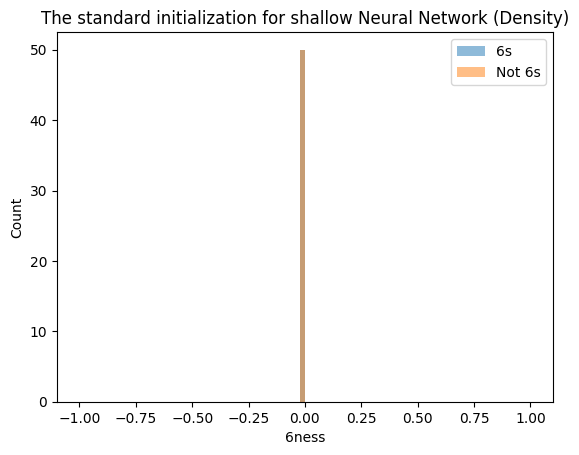

In [16]:
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.legend(['6s', 'Not 6s'])
plt.title("The standard initialization for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
class ShallowClassifier(nn.Module):
    def __init__(self):
        super(ShallowClassifier,self).__init__()
        self.fc1 = nn.Linear(num_features,MM)
        self.fc2 = nn.Linear(MM,1)     
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [ ]:
model = ShallowClassifier()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

In [ ]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-1,1))
plt.legend(['6s', 'Not 6s'])
plt.title("The standard (PyTorch) initialization for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()


In [17]:
def calculate_binary_metrics(predictions, truth):
    TT = np.sum((predictions[truth>0.5]>=0).astype(int))
    FF = np.sum((predictions[truth>0.5]<0).astype(int))
    TF = np.sum((predictions[truth<0.5]<0).astype(int))
    FT = np.sum((predictions[truth<0.5]>=0).astype(int))
    try:
        print(f"accuracy : {(TF+TT)/predictions.shape[0]}")
    except:
        print(" no accuracy ")
    try:
        print(f"precision : {(TT)/(TT+FT)}")    
    except:
        print(" no precision ")
    try:
        print(f"sensitivity or recall : {(TT)/(TT+FF)}")  
    except:
        print(" no sensitivity ")
    return TT,FF,TF,FT

In [18]:
#calculate_binary_metrics(check_output.detach().cpu().numpy(),y_test)
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.8777777777777778
precision : nan
sensitivity or recall : 0.0


/tmp/ipykernel_2355411/2652771362.py:11: RuntimeWarning: invalid value encountered in scalar divide
  print(f"precision : {(TT)/(TT+FT)}")


(0, 66, 474, 0)

Standard Metrics and Results for Standard Initialization.

In [ ]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

In [20]:
train_loss = []
test_loss = []
for epoch in range(200):
    costs = model.train(X_train.T, y_train.reshape(-1,1).T, epoch_num=1, batch_size=64,cost_fun='cross_entropy',lambd=0.01)
    train_loss.append(costs[0])
    check_output, __ = model.forward_pass(X_test.T,model.params,'cross_entropy')
    costs = gbnn.NeuralNet.cost(y_test.reshape(-1,1).T, check_output[0], "cross_entropy")
    test_loss.append(costs)

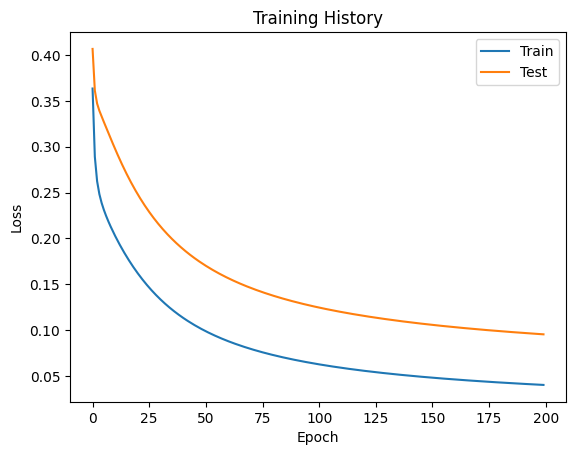

In [21]:
plt.plot(range(200),train_loss)
plt.plot(range(200),test_loss)
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [22]:
print(model.params)

(array([[ 0.14533003,  0.063474  , -0.10796955,  0.20632272, -0.08826874,
         0.55405125],
       [ 0.41256648,  0.04085972,  0.09622876,  0.6018608 , -0.60668243,
        -0.58388389],
       [ 0.39337303,  0.52327618,  0.67686854,  0.4230741 , -0.05447641,
         0.39672815],
       ...,
       [-0.19086028, -0.27359461, -0.05486829,  0.02674244,  0.01210012,
         0.37455154],
       [-0.60448193, -0.48218357,  0.01956107,  0.23643484,  0.41861534,
        -0.59861987],
       [ 0.50028269, -0.24709365, -0.01398291, -0.35553243, -0.6018529 ,
        -0.19372149]]), array([[ 0.09762717],
       [ 0.92733103],
       [-0.95956324],
       ...,
       [-0.30846074],
       [ 0.43298838],
       [-0.50147409]]), array([[-7.66553209e-04, -4.97726420e-03,  1.62690861e-06, ...,
        -4.50825060e-06,  5.70116108e-03, -1.43448659e-04]]), array([[-0.00275439]]))


In [ ]:
def train_model(model, max_epochs=20):
    history = {}
    history['loss']=[]
    history['test']=[]
    for epoch in range(max_epochs):  # loop over the dataset multiple times
    
        model.train()  
        running_loss = 0.0
        counter = 0
        for i, data in enumerate(trainloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels.reshape((-1, 1)))
            loss.backward()
            optimizer.step()
            # print statistics
            running_loss += loss.item()
            counter += 1
            #if i % 200 == 199:    # print every 2000 mini-batches
        #print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / counter:.3f}')
        history['loss'].append([epoch + 1, running_loss / counter])        
        running_loss = 0.0

        model.eval()    
        for i, data in enumerate(testloader, 0):
            # get the inputs; data is a list of [inputs, labels]
            inputs, labels = data


            # forward + backward + optimize
            outputs = model(inputs)
            loss = criterion(outputs, labels.reshape((-1, 1)))
            # print statistics
            running_loss += loss.item()
            counter += 1
            #if i % 200 == 199:    # print every 2000 mini-batches
        #print(f'Test [{epoch + 1}, {i + 1:5d}] loss: {running_loss / counter:.3f}')
        history['test'].append([epoch + 1, running_loss / counter])        
        running_loss = 0.0
    return history
    
history = train_model(model,80)
print('Finished Training')

In [ ]:
plt.plot(np.asarray(history['loss']).T[0],np.asarray(history['loss']).T[1])
plt.plot(np.asarray(history['test']).T[0],np.asarray(history['test']).T[1])
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.legend(['6s', 'Not 6s'])
plt.title("Trained for the Test Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

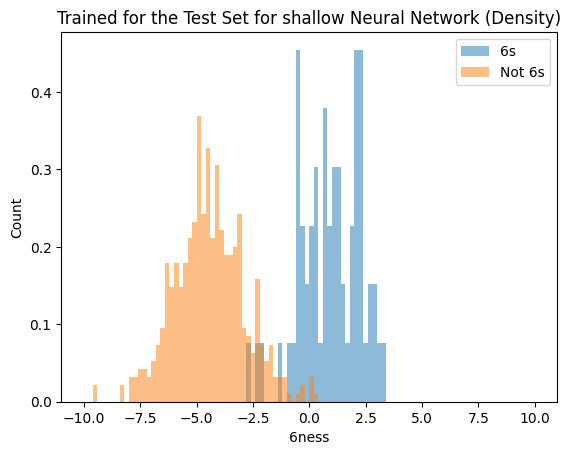

In [24]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.legend(['6s', 'Not 6s'])
plt.title("Trained for the Test Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [25]:
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.9611111111111111
precision : 0.9245283018867925
sensitivity or recall : 0.7424242424242424


(49, 17, 470, 4)

Standard Metrics and Results for Test set after Training.

In [ ]:
check_output = model(torch.Tensor(X_train))
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.legend(['6s', 'Not 6s'])
plt.title("Trained for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

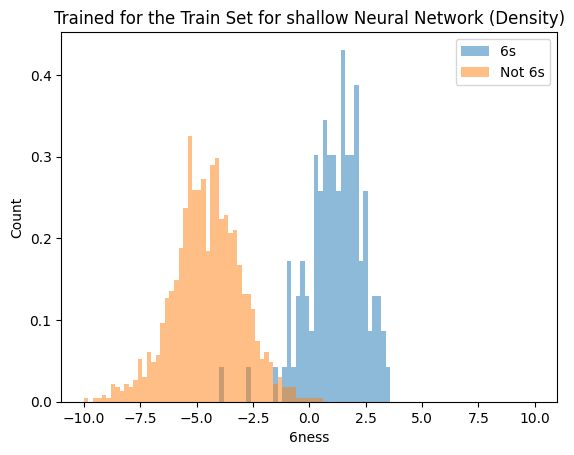

In [28]:
check_output, __ = model.forward_pass(X_train.T,model.params,'regression')
plt.hist(check_output[0][y_train>.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.hist(check_output[0][y_train<.5],alpha = 0.5,bins=100,density=True,range=(-10,10))
plt.legend(['6s', 'Not 6s'])
plt.title("Trained for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [29]:
calculate_binary_metrics(check_output[0],y_train)

accuracy : 0.9824980111376292
precision : 0.97
sensitivity or recall : 0.8362068965517241


(97, 19, 1138, 3)

Standard Metrics and Results for Train set after Training.

In [30]:
y_mod_test=y_test*20-10
y_mod_train=y_train*20-10
print(y_mod_test[:40])
print(y_test[:40])

[-10 -10 -10 -10 -10 -10  10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10 -10 -10  10 -10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10 -10 -10]
[0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0]


In [31]:
print(X_train)
tmin = np.min(X_train,axis=0)
tmax = np.max(X_train,axis=0)
print(tmax,tmin)
fmax=np.ones(6)
fmin=np.ones(6)
fmax[0]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmax[1]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmax[2]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmax[3]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmax[4]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmax[5]=np.max(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
fmin[0]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[0]-tmax[0])/100.)))
fmin[1]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[1]-tmax[1])/100.)))
fmin[2]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[2]-tmax[2])/100.)))
fmin[3]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[3]-tmax[3])/100.)))
fmin[4]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[4]-tmax[4])/100.)))
fmin[5]=np.min(np.fft.fftshift(np.fft.fftfreq(100,(tmin[5]-tmax[5])/100.)))
print(fmax,fmin)

[[-0.186918    0.29070262 -0.14840669 -0.09396869 -0.17134597 -0.06037818]
 [ 0.04218545 -0.65210759 -0.49401174  0.17319497 -0.29897839  0.2813934 ]
 [ 0.26067168 -0.17628657  0.74154545 -0.31831114  0.22084873  0.08123579]
 ...
 [-0.37203609 -0.40920258 -0.02649416  0.05929873 -0.65852863  0.10385512]
 [ 0.17374211 -0.31716085 -0.47627848  0.14565902 -0.09188309  0.17659723]
 [ 0.4550248  -0.51959735  0.41248495 -0.09871058 -0.21506541 -0.38486033]]
[1.         0.96988263 1.         1.         1.         0.96342908] [-0.98327384 -0.91367338 -0.89583534 -0.85828684 -0.78342207 -0.86180995]
[25.21084033 26.54553394 26.37359843 26.90650274 28.03598817 27.39367244] [-24.70662352 -26.01462326 -25.84612646 -26.36837269 -27.47526841
 -26.84579899]


In [32]:
grid_info = np.array([[fmin[j]/2, fmax[j]/2,24] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**2)
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 0.0, ycomp, 0))

 initializing with  13.0.0
 Diagnostics 
[[ -30.45  -30.02  -29.6  ...  -12.44  -12.01  -11.58]
 [ -77.8   -79.8   -81.8  ...  -82.06  -84.06  -86.06]
 [  65.56   65.     64.44 ...   42.03   41.47   40.88]
 ...
 [-107.56 -108.3  -109.06 ...  -69.3   -70.06  -70.8 ]
 [ -32.06  -33.34  -34.6  ...  -41.7   -42.97  -44.22]
 [ -32.8   -30.06  -27.34 ...   18.31   21.05   23.78]]


In [33]:
print(yf.shape,f.shape,yfu.shape,yfuc.shape)
yf = cp.asnumpy(yf)



(191102976,) (191102976, 6) (30,) (30,)


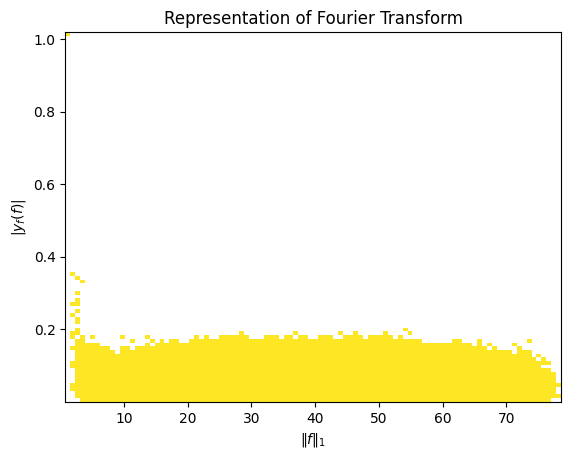

In [34]:
plt.hist2d(np.sum(np.abs(cp.asnumpy(f)),axis=1),np.abs(yf), bins=100,norm=colors.LogNorm(vmin=np.abs(yf).min(), vmax=np.abs(yf).max()))
plt.title("Representation of Fourier Transform")
plt.xlabel("$\|f\|_1$")
plt.ylabel("$|y_f(f)|$")
plt.show()

7077436.0


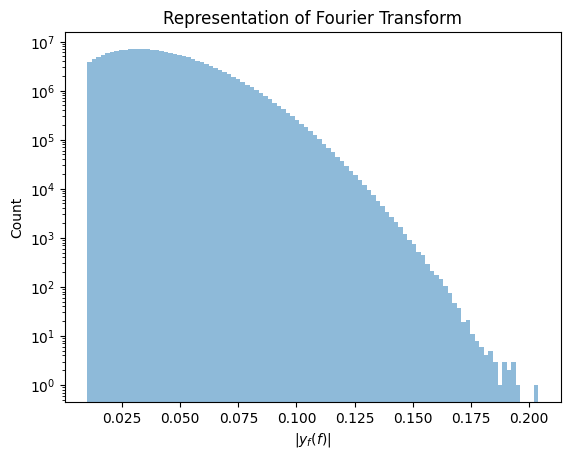

In [35]:
entries, bin_edges, patches = plt.hist(np.abs(yf),alpha = 0.5,bins=100, density=False,range=[0.01,.2*np.max(np.abs(yf))])
print(np.max(entries))
plt.yscale('log')
plt.title("Representation of Fourier Transform")
plt.ylabel("Count")
plt.xlabel("$|y_f(f)|$")
plt.show()

In [36]:
peak=np.argmax(entries, axis=None)
print(peak)
peakcorr = 1
sigma=(bin_edges[peak]+peakcorr*bin_edges[peak+1])/(1+peakcorr)
print(sigma)

11
0.03229692950844765


6957347.0


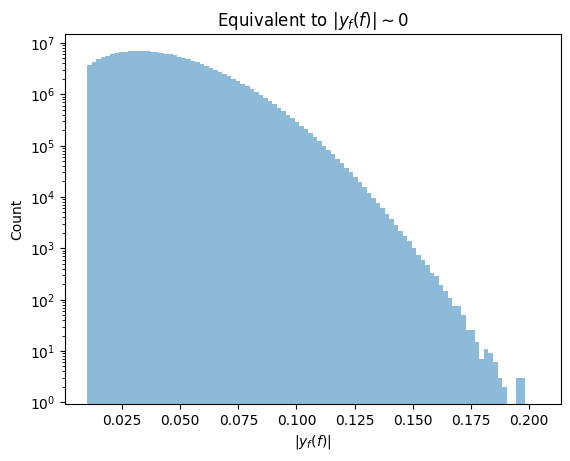

In [37]:
bentries, bbin_edges, bpatches = plt.hist(np.abs(np.random.normal(0, sigma, yf.shape[0])+1.j*np.random.normal(0, sigma, yf.shape[0])),alpha = 0.5,bins=100, density=False,range=[0.01,.2*np.max(np.abs(yf))])
print(np.max(bentries))
plt.yscale('log')
plt.title("Equivalent to $|y_f(f)| \sim 0$")
plt.ylabel("Count")
plt.xlabel("$|y_f(f)|$")
plt.show()

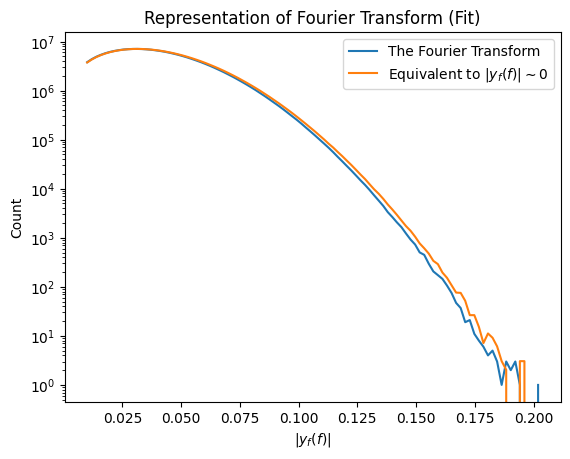

In [38]:
plt.plot(bin_edges[:100],entries)
plt.plot(bbin_edges[:100],bentries*np.max(entries)/np.max(bentries))
plt.yscale('log')
plt.legend(['The Fourier Transform', 'Equivalent to $|y_f(f)| \sim 0$'])
plt.title("Representation of Fourier Transform (Fit)")
plt.ylabel("Count")
plt.xlabel("$|y_f(f)|$")
plt.show()

We want to understand what the Fourier Transform would look like if every point was 0. It basically look like every point below around 0.2 is equivalent to 0. The peak is about at 0.032, which we can use to make our analysis simpler. Also, we see that the interesting parts of the Fourier Transform are at lower $\|f\|_1$.

In [39]:
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)
# we were sampling on a grid
# even the ones we set to 0, are not 'not sampled' but are rather set to 0
# the proper normalization is giong to be max()-min()/number along dimension
ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
with cp.cuda.Device(0):
    ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>.0].reshape(-1,1)/ycomp),cp.asarray(nf[np.abs(nyf)>.0,:]),0,2)

 Diagnostics 
(1257, 6)
(6, 191102976)
[[-77.56 -77.56 -77.56 -77.56]
 [-81.7  -81.7  -81.7  -81.7 ]
 [-81.2  -81.2  -81.2  -81.2 ]
 [-82.8  -82.8  -82.8  -82.8 ]
 [-86.25 -86.25 -86.25 -86.25]
 [-84.3  -77.2  -70.1  -63.  ]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06036]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.08124]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.07764]]
[[72.7  72.7  72.7  72.7 ]
 [76.44 76.44 76.44 76.44]
 [76.   76.   76.   76.  ]
 [77.56 77.56 77.56 77.56]
 [80.75 80.75 80.75 80.75]
 [57.62 64.75 71.8  78.94]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.4407    0.1909  ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1039  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[ 30.45  30.02  29.6  ... -27.67 -28.11 -28.53]
 [ 77.8   79.8   81.8  ... -76.8  -74.8  -72.8 ]]
 Diagnostics 
[[

In [40]:
print(f[:4,:])
print(f[-4:,:])
print(np.max(nf,axis=0))
print(np.min(nf,axis=0))

[[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -12.29 ]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -11.164]
 [-12.35  -13.01  -12.92  -13.19  -13.734 -10.03 ]]
[[11.57  12.17  12.1   12.35  12.86   9.17 ]
 [11.57  12.17  12.1   12.35  12.86  10.305]
 [11.57  12.17  12.1   12.35  12.86  11.44 ]
 [11.57  12.17  12.1   12.35  12.86  12.56 ]]
[11.57 12.17 12.1  12.35 12.86 12.56]
[-12.35  -13.01  -12.92  -13.19  -13.734 -13.42 ]


In [41]:
with cp.cuda.Device(0):
    print(ty[:20,:]*2*np.pi)
print(np.sqrt(2*np.pi))
print(ty.dtype)
print(y_mod_train[:20])
print(ycomp)

[[-10.65497176-8.06262905e-03j]
 [-10.64277219+2.74838785e-03j]
 [-10.65285205-1.45416526e-04j]
 [-10.64821265-1.40308272e-03j]
 [-10.64299202+5.71150995e-03j]
 [-10.64630978-3.12465898e-03j]
 [-10.64859615+1.22433552e-03j]
 [-10.63913048+2.13220742e-02j]
 [ 10.65021027-3.38516866e-04j]
 [-10.64987134+4.22417595e-06j]
 [-10.64920285-1.01985428e-03j]
 [-10.65214235+1.66097707e-04j]
 [-10.64939984-2.67175655e-04j]
 [-10.64824186+1.64043587e-03j]
 [-10.65665516+8.57193557e-04j]
 [-10.65926585+2.41691677e-03j]
 [-10.64997096+2.52597959e-03j]
 [-10.64881037+2.64310566e-03j]
 [-10.65146225+1.24305429e-03j]
 [-10.61272886+6.27755118e-03j]]
2.5066282746310002
complex128
[-10 -10 -10 -10 -10 -10 -10 -10  10 -10 -10 -10 -10 -10 -10 -10 -10 -10
 -10 -10]
142723.3125248111


We actually got pretty close to a good inverse Fourier Transform of our Fourier Transform ($y_f(f)$), or ty ($y_t$). We can compare this ty to y to see if our selection of when $|y_f(f)|\sim 0$.

In [42]:

with cp.cuda.Device(0):
    print(ty[:20,:]/np.median(cp.asnumpy(ty))*np.median(y_mod_train))
    print(" the rms is ",rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))
    print(" the real rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).real,y_mod_train))
    print(" the imag rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).imag,y_mod_train*0))
    print(" the imag rms is (no corr) ",rmse(cp.asnumpy(ty).imag,y_mod_train*0))

[[-10.00296996-7.92029434e-03j]
 [ -9.99151726+2.22957420e-03j]
 [-10.00098022-4.87483910e-04j]
 [ -9.99662468-1.66803785e-03j]
 [ -9.99172374+5.01136899e-03j]
 [ -9.99483819-3.28420432e-03j]
 [ -9.99698479+7.98590164e-04j]
 [ -9.98809901+1.96668151e-02j]
 [  9.99850012+3.30764486e-05j]
 [ -9.99818192-3.46901856e-04j]
 [ -9.99755429-1.30829263e-03j]
 [-10.00031396-1.95008548e-04j]
 [ -9.99773925-6.01678590e-04j]
 [ -9.9966522 +1.18924008e-03j]
 [-10.00455065+4.53648925e-04j]
 [-10.00700163+1.91784317e-03j]
 [ -9.99827552+2.02053843e-03j]
 [ -9.99718595+2.13053553e-03j]
 [ -9.99967551+8.16069064e-04j]
 [ -9.96331247+5.54376993e-03j]]
 the rms is  (8.188659258283224+0j)
 the real rms is  8.18864926888505
 the imag rms is  0.012790603852319732
 the imag rms is (no corr)  0.0021675542526805426


We can rescale to improve.

In [43]:
mempool = cp.get_default_memory_pool()
print(mempool.used_bytes())
print(mempool.total_bytes())
try:
    del calcdft
except:
    print(" nothing to delete ")
    
try:
    del yf
except:
    print(" nothing to delete ")

try:
    del f 
except:
    print(" nothing to delete ")
    
try:
    del yfu
except:
    print(" nothing to delete ")
    
try:
    del yfuc
except:
    print(" nothing to delete ")
mempool.free_all_blocks()
print(mempool.used_bytes())
print(mempool.total_bytes())

2293282816
16053333504
20480
643584


In [44]:
tlist = [0.03,0.04,0.05,0.06,0.1,0.15,0.2,0.25,0.3,0.4,0.45,0.5,0.6,0.7,0.8,0.9,1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.7,1.8,1.9,2.0,2.1,2.2,2.3,2.4,2.5]

In [45]:
grid_info = np.array([[fmin[j]/8, fmax[j]/8,24] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**1)
start = time.time()
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
print(X_train.shape,y_train.shape)
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 1*sigma, ycomp, 0))
print(mempool.used_bytes())
print(mempool.total_bytes())

 initializing with  13.0.0
(1257, 6) (1257,)
 Diagnostics 
[[ 1.212   1.195   1.178  ...  0.4949  0.4778  0.4607]
 [ 3.098   3.178   3.258  ...  3.268   3.346   3.426 ]
 [-2.61   -2.586  -2.562  ... -1.673  -1.649  -1.627 ]
 ...
 [ 4.28    4.312   4.34   ...  2.76    2.79    2.818 ]
 [ 1.276   1.326   1.376  ...  1.659   1.709   1.759 ]
 [ 1.307   1.197   1.089  ... -0.7285 -0.837  -0.946 ]]
3534802944
22391478784


We can do the calculation at lower $f$. And we can also put a cut on $y_f(f)$ using the previously identified peak (around $\sigma \sim 0.032$).

[8.289645  7.909916  7.45788   ... 2.5070114 2.909388  2.8764727]
190549660.0
3534802944
22391478784


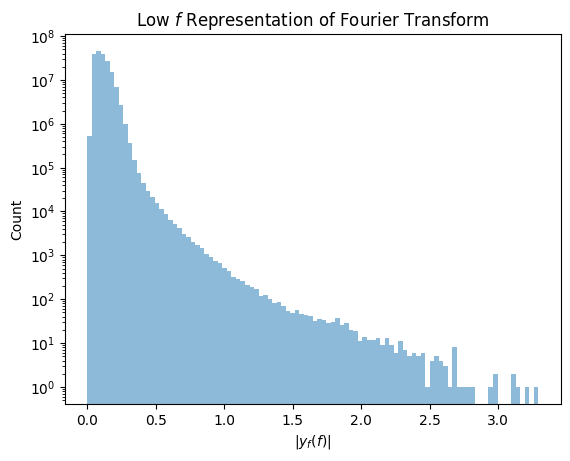

In [46]:
cp.heaviside(cp.abs(yf)-0.032,0.5)*yf
_, _, _= plt.hist(cp.asnumpy(cp.abs(cp.heaviside(cp.abs(yf)-0.032,0.5)*yf)),alpha = 0.5,bins=100, density=False,range=[0,np.max(np.abs(cp.asnumpy(yf)))])
print(cp.asnumpy(cp.heaviside(cp.abs(yf)-0.032,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)))
print(cp.asnumpy(cp.heaviside(cp.abs(yf)-0.032,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)).sum())
print(mempool.used_bytes())
print(mempool.total_bytes())
plt.yscale('log')
plt.title("Low $f$ Representation of Fourier Transform")
plt.ylabel("Count")
plt.xlabel("$|y_f(f)|$")
plt.show()

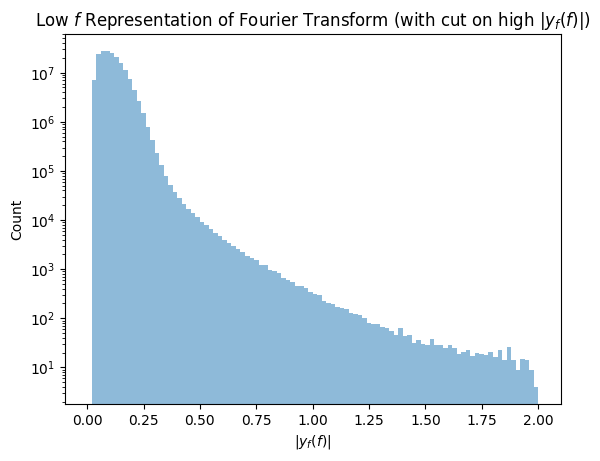

In [47]:
cp.heaviside(cp.abs(yf)-0.032,0.5)*yf
_, _, _= plt.hist(cp.asnumpy(cp.abs(cp.heaviside(cp.abs(yf)-0.032,0.5)*yf)),alpha = 0.5,bins=100, density=False,range=[0,2])
plt.yscale('log')
plt.title("Low $f$ Representation of Fourier Transform (with cut on high $|y_f(f)|$)")
plt.ylabel("Count")
plt.xlabel("$|y_f(f)|$")
plt.show()

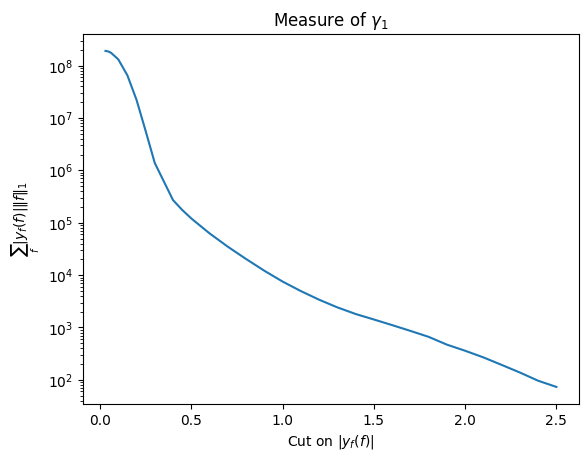

In [48]:
plt.plot(tlist,[cp.asnumpy(cp.heaviside(cp.abs(yf)-t,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)).sum() for t in tlist])
plt.yscale('log')
plt.title("Measure of $\gamma_1$")
plt.ylabel("$\sum_f |y_f(f)| \|f\|_1$")
plt.xlabel("Cut on $|y_f(f)|$")
plt.show()

In [49]:
print(yf)
print(yf.shape)
print(cp.abs(yf)>.06)
print(f.shape)
print(f[cp.abs(yf)>.06,:].shape)
print(X_train.shape)
print(y_train.shape)

[-0.33908793-0.2507513j  -0.31513837-0.25953597j -0.28520018-0.26687738j
 ...  0.13994908+0.01240756j  0.14829047+0.06144877j
  0.10343387+0.11714914j]
(176737777,)
[ True  True  True ...  True  True  True]
(176737777, 6)
(145990729, 6)
(1257, 6)
(1257,)


In [50]:
print(f[cp.abs(yf)>.06,:][:4,:6])
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)

[[-3.088 -3.252 -3.23  -3.297 -3.434 -3.355]
 [-3.088 -3.252 -3.23  -3.297 -3.434 -3.072]
 [-3.088 -3.252 -3.23  -3.297 -3.434 -2.791]
 [-3.088 -3.252 -3.23  -3.297 -3.434 -2.508]]


In [51]:
ycomp = (1/nf[np.abs(nyf)>.06,:].shape[0])/(np.sqrt(2*np.pi)**1)
#ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>.06].reshape(-1,1)*ycomp),cp.asarray(nf[np.abs(nyf)>.06,:]),0,2)

 Diagnostics 
(1257, 6)
(6, 145990729)
[[-19.39 -19.39 -19.39 -19.39]
 [-20.42 -20.42 -20.42 -20.42]
 [-20.3  -20.3  -20.3  -20.3 ]
 [-20.7  -20.7  -20.7  -20.7 ]
 [-21.56 -21.56 -21.56 -21.56]
 [-21.08 -19.3  -17.53 -15.75]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06036]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.08124]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.07764]]
[[18.17 18.17 18.17 18.17]
 [19.11 19.11 19.11 19.11]
 [19.   19.   19.   19.  ]
 [19.39 19.39 19.39 19.39]
 [20.19 20.19 20.19 20.19]
 [14.41 16.19 17.95 19.73]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.4407    0.1909  ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1039  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[  7.613   7.504   7.4   ...  -6.918  -7.027  -7.133]
 [ 19.45   19.95   20.45  ... -19.2   -18.7   -18.2  ]]
 Dia

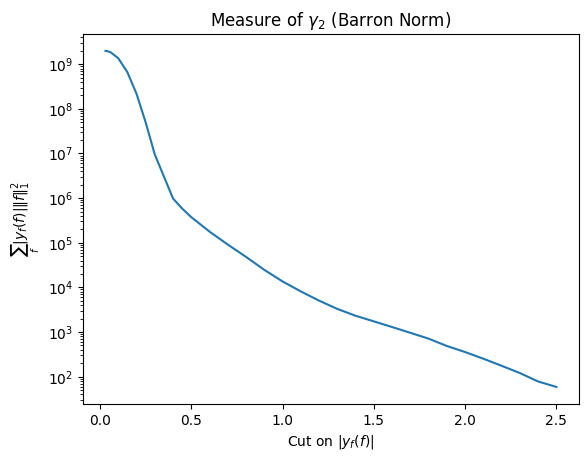

In [52]:
plt.plot(tlist,[cp.asnumpy(cp.heaviside(cp.abs(yf)-t,0.5)*cp.abs(yf)*cp.sum(cp.abs(f),axis=1)*cp.sum(cp.abs(f),axis=1)).sum() for t in tlist])
plt.yscale('log')
plt.title("Measure of $\gamma_2$ (Barron Norm)")
plt.ylabel("$\sum_f |y_f(f)| \|f\|_1^2$")
plt.xlabel("Cut on $|y_f(f)|$")
plt.show()

Recall that in the theory, the effective target function is defined such as to minimize the Barron Norm. This same Barron Norm is a bound on the approximation error. Obviously the higher we place the cut (the more of $y_f(f)$ that we identify as 0, due to our Fourier Transform being only an approximation), the lower the Barron Norm ($\gamma_2$) is.

In [53]:
print(ty)
print(ty.dtype)

[[-0.00138783-4.26950810e-05j]
 [-0.00152843+2.45880324e-06j]
 [-0.0017235 -7.88495754e-07j]
 ...
 [-0.00158015+3.69492545e-06j]
 [-0.00143415-4.12983372e-05j]
 [ 0.        +0.00000000e+00j]]
complex128


In [54]:
print(f.shape)
print(yf.shape)
print(f)
print(yf)
print(yf.dtype)
print(nyf.dtype)

(176737777, 6)
(176737777,)
[[-3.088 -3.252 -3.23  -3.297 -3.434 -3.355]
 [-3.088 -3.252 -3.23  -3.297 -3.434 -3.072]
 [-3.088 -3.252 -3.23  -3.297 -3.434 -2.791]
 ...
 [ 2.893  3.043  3.025  3.088  3.215  2.576]
 [ 2.893  3.043  3.025  3.088  3.215  2.86 ]
 [ 2.893  3.043  3.025  3.088  3.215  3.14 ]]
[-0.33908793-0.2507513j  -0.31513837-0.25953597j -0.28520018-0.26687738j
 ...  0.13994908+0.01240756j  0.14829047+0.06144877j
  0.10343387+0.11714914j]
complex64
complex64


In [55]:
print(mempool.total_bytes())
mempool.free_all_blocks()


24143367680


In [56]:
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)

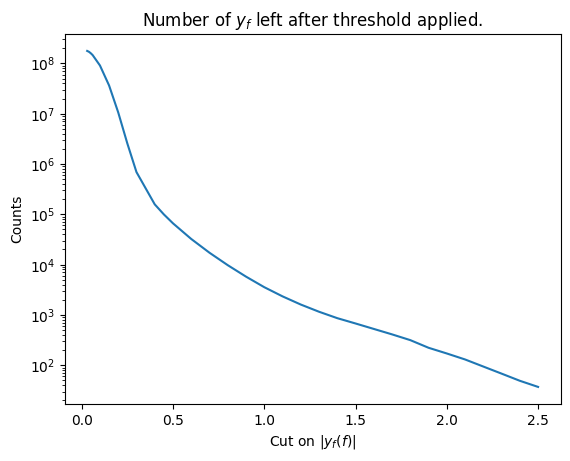

In [57]:
#for t in tlist:
#    print(" for threshold ",t," the size is ",nf[np.abs(nyf)>t,:].shape[0])
plt.plot(tlist,[nf[np.abs(nyf)>t,:].shape[0] for t in tlist])
plt.yscale('log')
plt.title("Number of $y_f$ left after threshold applied.")
plt.ylabel("Counts")
plt.xlabel("Cut on $|y_f(f)|$")
plt.show()

Obviously, we also need a reasonable number of counts after the threshold is applied to get a good estimate of our $y_f$. This is another factor to consider when selecting the threshold.

In [58]:
mempool = cp.get_default_memory_pool()
#print(mempool.used_bytes())
#print(mempool.total_bytes())
#try:
#    del calcdft
#except:
#    print(" nothing to delete ")
    
#try:
#    del yf
#except:
#    print(" nothing to delete ")

#try:
#    del f 
#except:
#    print(" nothing to delete ")
    
#try:
#    del yfu
#except:
#    print(" nothing to delete ")
    
#try:
#    del yfuc
#except:
#    print(" nothing to delete ")
#mempool.free_all_blocks()
#print(mempool.used_bytes())
#print(mempool.total_bytes())

We might want to clear memory off our GPU.

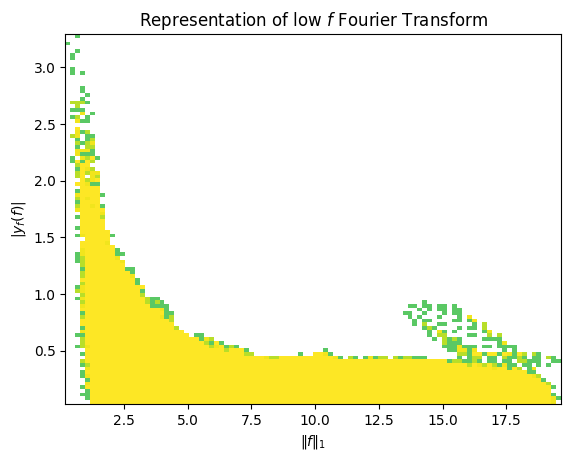

In [59]:
plt.hist2d(np.sum(np.abs(nf),axis=1),np.abs(nyf), bins=100,norm=colors.LogNorm(vmin=np.abs(nyf).min(), vmax=np.abs(nyf).max()))
plt.title("Representation of low $f$ Fourier Transform")
plt.xlabel("$\|f\|_1$")
plt.ylabel("$|y_f(f)|$")
plt.show()

We can see that the structure is pretty dominant for $|y_f(f)|>0.5$ and $\|f\|_1<7.5$. Sometimes I see some artifact at 15-20. We could make a more complicated sampling and possibly we could go to even another factor of 2 lower $f$.

In [60]:
bestinvft = []
for t in tlist:
    try:
        del calcinvdft
    except:
        print(" nothing to delete ")
    try:
        del cyc
    except:
        print(" nothing to delete ")
    try:
        del syc
    except:
        print(" nothing to delete ")  
    mempool.free_all_blocks()
    start = time.time()
    ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
    with cp.cuda.Device(0):
        ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>t].reshape(-1,1)/ycomp),cp.asarray(nf[np.abs(nyf)>t,:]),0,2)
    end = time.time()
    print(" the time is ",end-start)
    print(" the threshold is ",t)
    with cp.cuda.Device(0):
        #print(ty[:20,:]/np.median(cp.asnumpy(ty))*np.median(y_mod_train))
        print(" the rms is ",rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))
        print(" the real rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).real,y_mod_train))
        print(" the imag rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).imag,y_mod_train*0))
        print(" the imag rms is (no corr) ",rmse(cp.asnumpy(ty).imag,y_mod_train*0))
        bestinvft.append(rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))


 nothing to delete 
 nothing to delete 
 nothing to delete 
 Diagnostics 
(1257, 6)
(6, 176737777)
[[-19.39 -19.39 -19.39 -19.39]
 [-20.42 -20.42 -20.42 -20.42]
 [-20.3  -20.3  -20.3  -20.3 ]
 [-20.7  -20.7  -20.7  -20.7 ]
 [-21.56 -21.56 -21.56 -21.56]
 [-21.08 -19.3  -17.53 -15.75]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06036]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.08124]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.07764]]
[[18.17 18.17 18.17 18.17]
 [19.11 19.11 19.11 19.11]
 [19.   19.   19.   19.  ]
 [19.39 19.39 19.39 19.39]
 [20.19 20.19 20.19 20.19]
 [14.41 16.19 17.95 19.73]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.4407    0.1909  ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1039  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[  7.613   7.504   7.4   ...  -6.918  -7.027  -7.133]


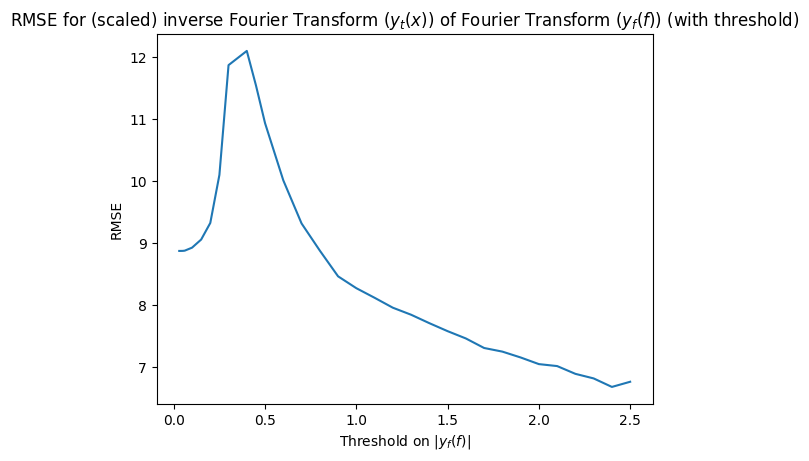

In [61]:
plt.plot(tlist,np.abs(bestinvft))
#plt.yscale('log')
plt.title("RMSE for (scaled) inverse Fourier Transform ($y_t(x)$) of Fourier Transform ($y_f(f)$) (with threshold)")
plt.ylabel("RMSE")
plt.xlabel("Threshold on $|y_f(f)|$")
plt.show()

Note that it rapidly increases but then decreases to a minimum near 2.4. This suggest placing the threshold nowhere near 0.5 and probably well after 0.8.

In [62]:
ycomp = np.prod([(np.pi*(fmax[i]-fmin[i])/4)/23 for i in range(6)])
print((nyf[np.abs(nyf)>0.31].reshape(-1,1)/ycomp).dtype)
print((nyf[np.abs(nyf)>0.31].reshape(-1,1)/ycomp).shape)
print(nf.dtype)
threshold = 2.0
pdf=bounds.E_pdf(np.abs(nyf[np.abs(nyf)>threshold].reshape(-1,1)/ycomp).astype('float64'),2*np.pi*((nf[np.abs(nyf)>threshold,:]).T).astype('float64'))

complex64
(556255, 1)
float16


In [63]:
MM=8000
zv, tv, wv, sv = pdf.gen_ztw(MM)
wh, wn = bounds.nn_wnorm(wv)
print(wh.shape)
print(zv.shape)
print(sv.shape)
print(sv)

(6, 8000)
(8000,)
(8000,)
[-1.  1. -1. ...  1.  1. -1.]


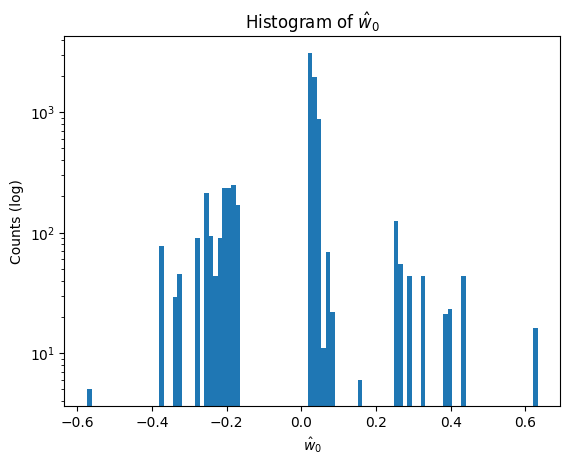

In [64]:
plt.hist(wh[0,:],bins=100)
plt.yscale('log')
plt.title("Histogram of $\hat{w}_0$")
plt.ylabel("Counts (log)")
plt.xlabel("$\hat{w}_0$")
plt.show()

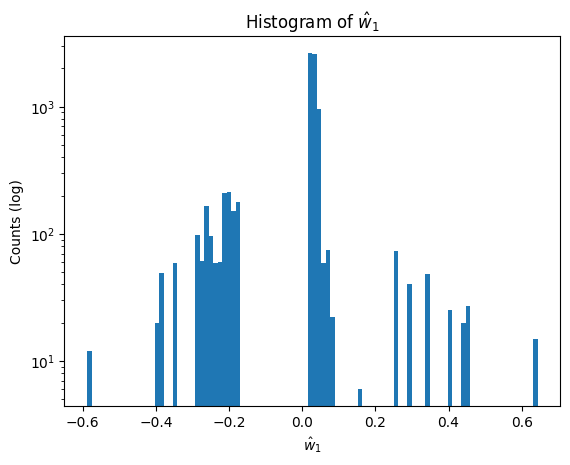

In [65]:
plt.hist(wh[1,:],bins=100)
plt.yscale('log')
plt.title("Histogram of $\hat{w}_1$")
plt.ylabel("Counts (log)")
plt.xlabel("$\hat{w}_1$")
plt.show()

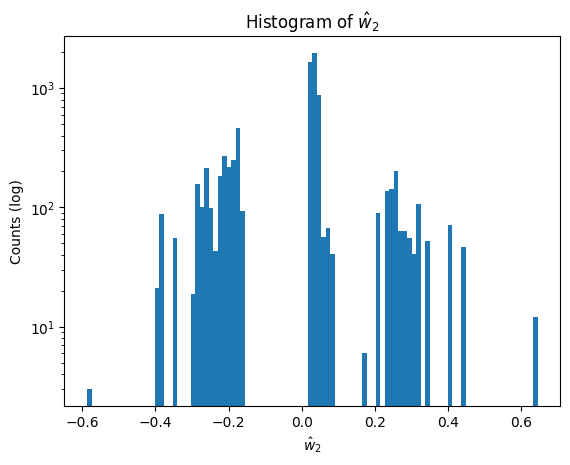

In [66]:
plt.hist(wh[2,:],bins=100)
plt.yscale('log')
plt.title("Histogram of $\hat{w}_2$")
plt.ylabel("Counts (log)")
plt.xlabel("$\hat{w}_2$")
plt.show()

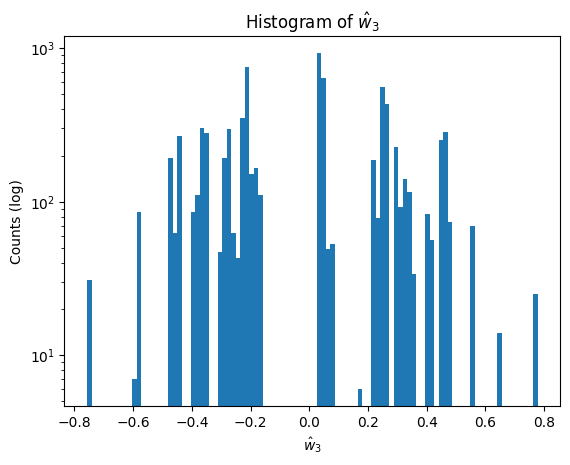

In [67]:
plt.hist(wh[3,:],bins=100)
plt.yscale('log')
plt.title("Histogram of $\hat{w}_3$")
plt.ylabel("Counts (log)")
plt.xlabel("$\hat{w}_3$")
plt.show()

We try to get some understanding of the shape of the PDF using the histograms of $\hat{w}$. This shows that there isn't just a peak at $1/n_{feat}$ which we might expect if the target function was not interesting. Sharp peaks stand out.

In [68]:
df = pd.DataFrame(wh.T, columns=["W0", "W1","W2","W3","W4","W5"])
df['Norm'] = wn
df['T'] = zv*tv

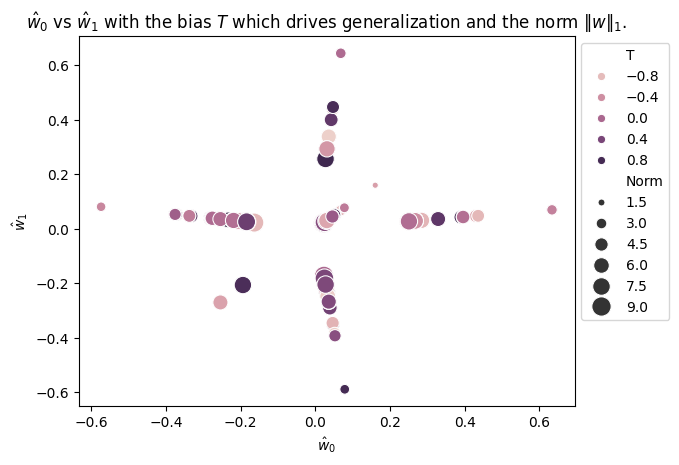

In [69]:
ax = sns.scatterplot(x='W0', y='W1', hue='T', size='Norm', sizes=(20, 200), data=df)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("$\hat{w}_0$ vs $\hat{w}_1$ with the bias $T$ which drives generalization and the norm $\|w\|_1$.")
plt.ylabel("$\hat{w}_1$")
plt.xlabel("$\hat{w}_0$")
plt.show()

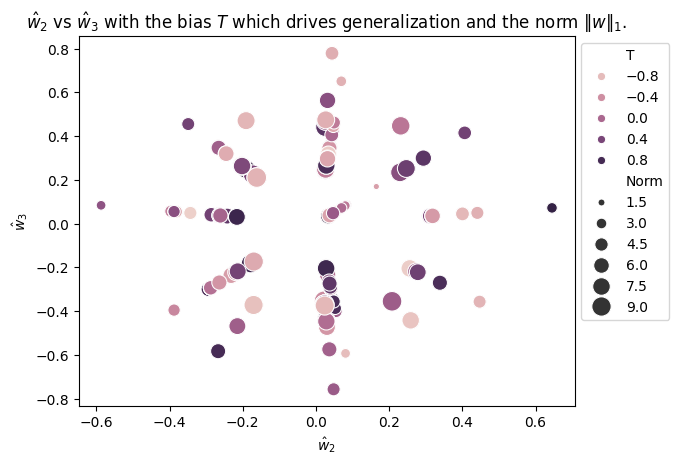

In [70]:
ax = sns.scatterplot(x='W2', y='W3', hue='T', size='Norm', sizes=(20, 200), data=df)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("$\hat{w}_2$ vs $\hat{w}_3$ with the bias $T$ which drives generalization and the norm $\|w\|_1$.")
plt.ylabel("$\hat{w}_3$")
plt.xlabel("$\hat{w}_2$")
plt.show()

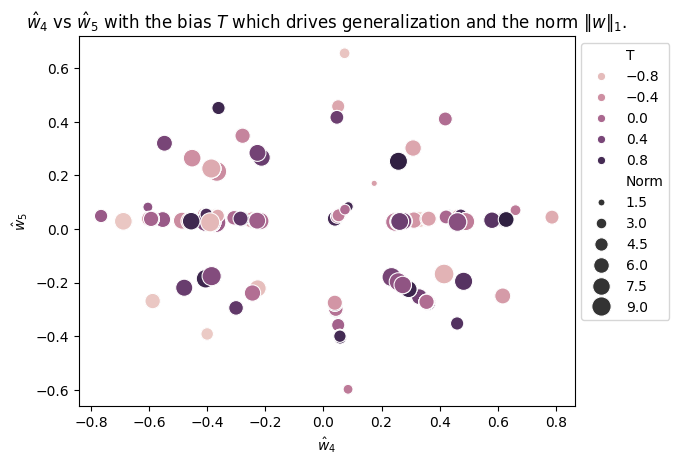

In [71]:
ax = sns.scatterplot(x='W4', y='W5', hue='T', size='Norm', sizes=(20, 200), data=df)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title("$\hat{w}_4$ vs $\hat{w}_5$ with the bias $T$ which drives generalization and the norm $\|w\|_1$.")
plt.ylabel("$\hat{w}_5$")
plt.xlabel("$\hat{w}_4$")
plt.show()

Plots like these give some understanding of the structure as well as the main contributions of the effective target function. We could also consider plotting things like $n_{feat}-1$ number of angles or binning in $\hat{w}$.

In [72]:
mask = dft.threshold_cmask(nyf,2.4)
print(nf.shape)
print(nyf.shape)
print(nyf[np.abs(nyf)>2.4].shape)
sne = bounds.est_spec_norm(nf[np.abs(nyf)>2.4,:]*2*np.pi,nyf[np.abs(nyf)>2.4].reshape(-1,1),[(np.pi*(fmax[i]-fmin[i])/4)/23 for i in range(6)],None)
print(sne)
print(" did I get the bandwidth right? ")
sne = bounds.est_spec_norm(nf[np.abs(nyf)>2.4,:]*2*np.pi,nyf[np.abs(nyf)>2.4].reshape(-1,1),None,mask)
print(sne)
print(" this is incorrect because it doesn't properly account for all the 0 ")
try:
    sne = bounds.est_spec_norm(nf*2*np.pi,nyf.reshape(-1,1),None,mask)
    print(sne)
except:
    print(" this is too big ")

(176737777, 6)
(176737777,)
(49,)
 this is assuming that only 49 points are tested, not that other poitns are tested and 0
543791.3280414409
 did I get the bandwidth right? 
 this is assuming that only 49 points are tested, not that other poitns are tested and 0
2638228993.0995507
 this is incorrect because it doesn't properly account for all the 0 
 this is too big 


In [73]:
abnd = bounds.apriori_bound(sne,MM,1700,2,0.95)
print(abnd)

2610096287222546.5


In [102]:
model=gbnn.NeuralNet(num_features,MM)
print(model.params)
model.barron_init(num_features,(wh.T),(tv*zv).reshape(-1,1),((-1000)*(sv).reshape(-1,1).T/MM),np.array([[0]]))
print(model.params)


(array([[ 0.16838085,  0.39953949,  0.51240966,  0.32416173,  0.12966115,
         0.2372471 ],
       [-0.14332146,  0.50949119,  0.49044871,  0.44468338,  0.46237064,
        -0.18318265],
       [ 0.30696434, -0.17941509, -0.41827082,  0.20508833, -0.42472716,
        -0.70185599],
       ...,
       [-0.14417529, -0.11009433, -0.29463653, -0.22210492,  0.28674834,
        -0.57336029],
       [-0.66258324, -0.28466574,  0.24815384, -0.25208553, -0.62053652,
        -0.07632013],
       [-0.51451239,  0.51452964,  0.54483847, -0.08917027,  0.53877616,
        -0.47480568]]), array([[-0.91994725],
       [ 0.32888929],
       [-0.80904035],
       ...,
       [ 0.84730481],
       [ 0.33988293],
       [ 0.86088257]]), array([[ 3.97144924e-05,  6.35661805e-05,  1.14357239e-04, ...,
        -1.11657902e-04, -8.18447135e-05, -2.54883036e-05]]), array([[0.]]))
(array([[-0.1646955 ,  0.02330097, -0.17263901,  0.22541924,  0.23442189,
        -0.17952339],
       [ 0.02552698,  0.02552698

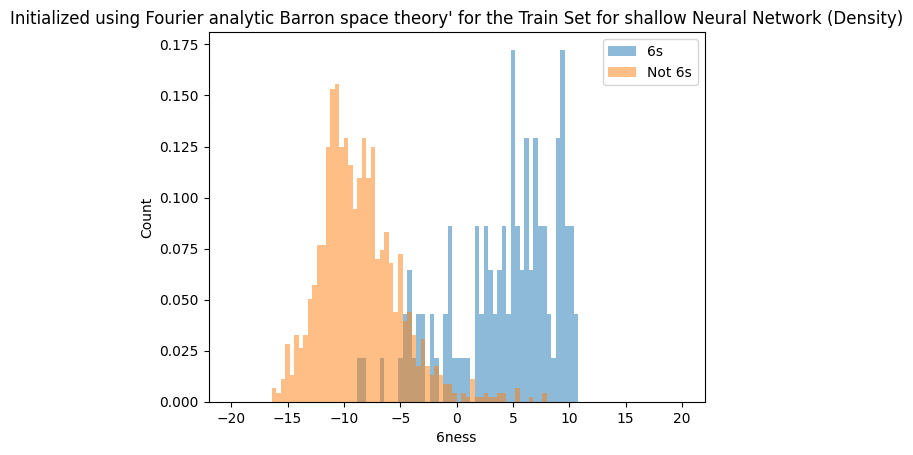

In [103]:
check_output, __ = model.forward_pass(X_train.T,model.params,'regression')
plt.hist(check_output[0][y_train>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_train<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [104]:
calculate_binary_metrics(check_output[0],y_train)

accuracy : 0.9618138424821002
precision : 0.7931034482758621
sensitivity or recall : 0.7931034482758621


(92, 24, 1117, 24)

In [ ]:
class ShallowClassifierInit(nn.Module):
    def __init__(self, mean=0, max=1000):
        super(ShallowClassifierInit,self).__init__()
        self.fc1 = nn.Linear(num_features,MM)
        self.fc2 = nn.Linear(MM,1)     
        self.fc1.weight = torch.nn.Parameter(torch.Tensor(wh.T))
        self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([mean])))
        self.fc2.weight = torch.nn.Parameter(torch.Tensor((-max)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

I can use the available information to improve my initialization.

In [ ]:
model = ShallowClassifierInit()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

Now when we initializae the network, we initialize the network based on the draws from the pdf. There  is an overall factor on the second connected layers weights and bias which are set by the properties of the effective target function in $x\in[0,1]^d$.

In [ ]:
check_output = model(torch.Tensor(X_train))
print(check_output.detach().cpu().numpy()[y_train>.5].shape)
print(check_output.detach().cpu().numpy()[y_train<.5].shape)
print(np.median(check_output.detach().cpu().numpy()[y_train<.5]))
print(np.median(check_output.detach().cpu().numpy()[y_train>.5]))
print(check_output.T)
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()


We now have a good initialization of the network, and an initialization that should generalize well. This is with a threshold of 2.0.

In [ ]:
model = ShallowClassifierInit(mean=-np.median(check_output.detach().cpu().numpy()[y_train<.5])/2-np.median(check_output.detach().cpu().numpy()[y_train>.5])/2)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

In [ ]:
#model.barron_init(num_features,(wh.T),(tv*zv).reshape(-1,1),((-1000)*(sv).reshape(-1,1).T/MM),np.array([[np.median(check_output[0][y_train<.5])+np.median(check_output[0][y_train>.5])]]))

We use the network to correct the second layers weights and biases.

In [ ]:
#print(model.params)

In [ ]:
print(model)
print(torch.Tensor(X_test).shape)
print(model.fc2.bias)

In [ ]:
check_output = model(torch.Tensor(X_train))
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
calculate_binary_metrics(check_output.detach().cpu().numpy(),y_train)

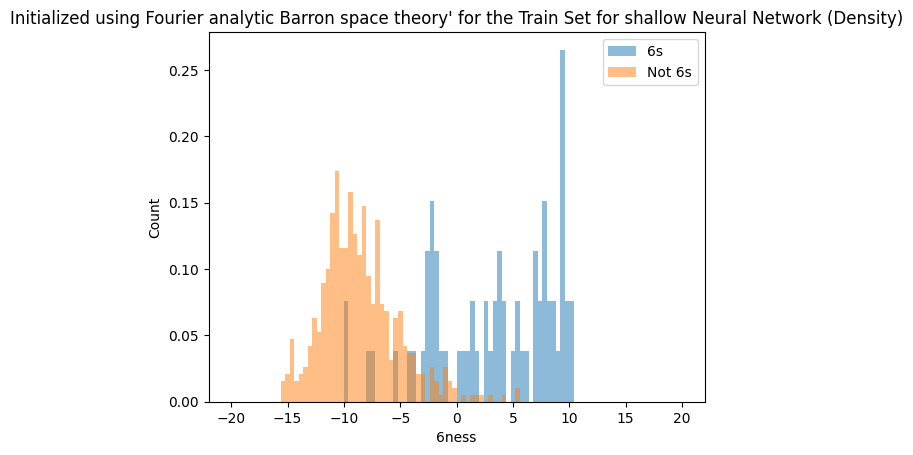

In [105]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [106]:
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.9481481481481482
precision : 0.8518518518518519
sensitivity or recall : 0.696969696969697


(46, 20, 466, 8)

In [ ]:
loss = criterion(check_output, torch.Tensor(y_train).reshape((-1, 1)))
print(loss)

In [ ]:
check_output = model(torch.Tensor(X_test))
print(check_output.detach().cpu().numpy()[y_test>.5].shape)
print(check_output.detach().cpu().numpy()[y_test<.5].shape)
#print(check_output.T)
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
calculate_binary_metrics(check_output.detach().cpu().numpy(),y_test)

In [ ]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

In [107]:
train_loss = []
test_loss = []
for epoch in range(200):
    costs = model.train(X_train.T, y_train.reshape(-1,1).T, epoch_num=1, batch_size=64,cost_fun='cross_entropy',lambd=0.01)
    train_loss.append(costs[0])
    check_output, __ = model.forward_pass(X_test.T,model.params,'cross_entropy')
    costs = gbnn.NeuralNet.cost(y_test.reshape(-1,1).T, check_output[0], "cross_entropy")
    test_loss.append(costs)

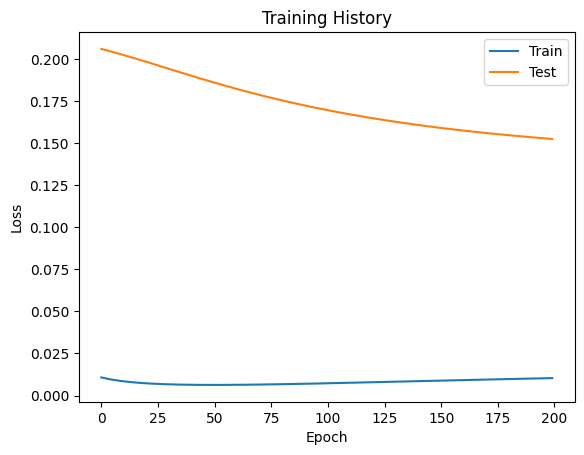

In [108]:
plt.plot(range(200),train_loss)
plt.plot(range(200),test_loss)
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
history = train_model(model,90)

print('Finished Training')

In [ ]:
plt.plot(np.asarray(history['loss']).T[0],np.asarray(history['loss']).T[1])
plt.plot(np.asarray(history['test']).T[0],np.asarray(history['test']).T[1])
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

Now we can see the result of the training. We actually reach the minimal loss in shorter time.

In [ ]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density) after training.")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

In [ ]:
calculate_binary_metrics(check_output.detach().cpu().numpy(),y_test)

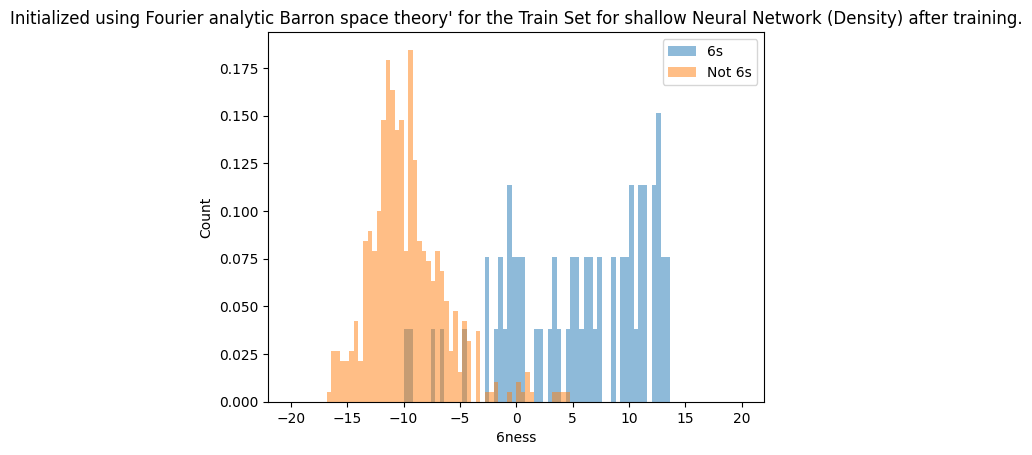

In [109]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density) after training.")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [110]:
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.95
precision : 0.819672131147541
sensitivity or recall : 0.7575757575757576


(50, 16, 463, 11)

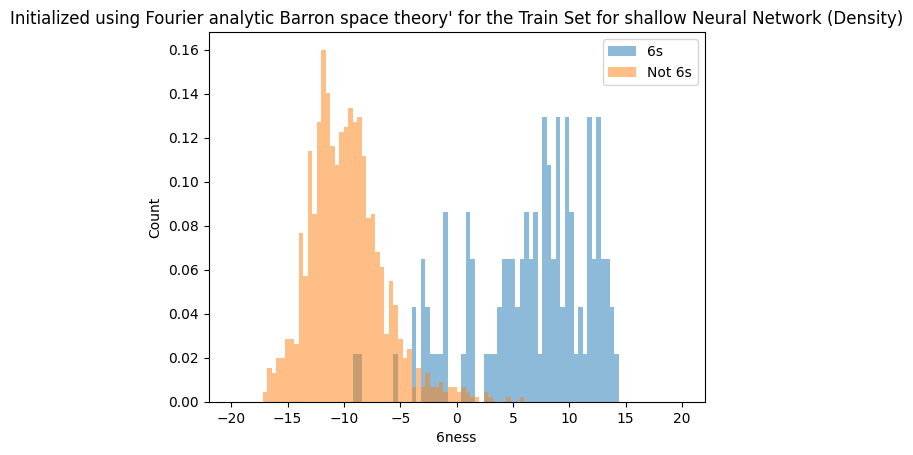

In [111]:
check_output, __ = model.forward_pass(X_train.T,model.params,'regression')
plt.hist(check_output[0][y_train>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_train<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [114]:
calculate_binary_metrics(check_output[0],y_train)

accuracy : 0.9753381066030231
precision : 0.8761061946902655
sensitivity or recall : 0.853448275862069


(99, 17, 1127, 14)

We could improve by using a better resolution approximate Fourier transform, or by including more nodes in the neural network, or by adjusting the threshold.

In [115]:
grid_info = np.array([[fmin[j]/16, fmax[j]/16,24] for j in np.arange(6)])
ycomp = (1/X_train.shape[0])/(np.sqrt(2*np.pi)**1)
start = time.time()
calcdft = dft.nu_dft_cupy(X_train, y_mod_train,[0])
print(X_train.shape,y_train.shape)
yf, f, yfu, yfuc = (calcdft.process_grid(grid_info, 1*sigma, ycomp, 0))
print(mempool.used_bytes())
print(mempool.total_bytes())

 initializing with  13.0.0
(1257, 6) (1257,)
 Diagnostics 
[[ 0.505    0.505    0.505   ...  0.257    0.257    0.257  ]
 [ 2.021    2.021    2.021   ...  1.589    1.589    1.589  ]
 [-1.168   -1.168   -1.168   ... -0.849   -0.849   -0.849  ]
 ...
 [ 2.316    2.316    2.316   ...  1.363    1.363    1.363  ]
 [ 0.9346   0.9346   0.9346  ...  0.802    0.802    0.802  ]
 [ 0.00764  0.00764  0.00764 ... -0.3032  -0.3032  -0.3032 ]]
3676315648
21908739072


In [116]:
nf=cp.asnumpy(f)
nyf=cp.asnumpy(yf)

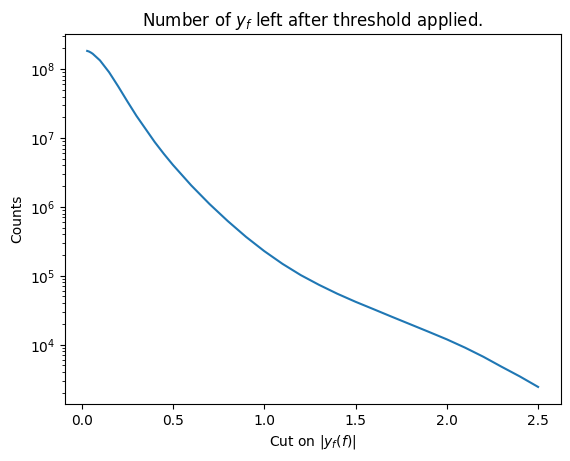

In [117]:
#for t in tlist:
#    print(" for threshold ",t," the size is ",nf[np.abs(nyf)>t,:].shape[0])
plt.plot(tlist,[nf[np.abs(nyf)>t,:].shape[0] for t in tlist])
plt.yscale('log')
plt.title("Number of $y_f$ left after threshold applied.")
plt.ylabel("Counts")
plt.xlabel("Cut on $|y_f(f)|$")
plt.show()

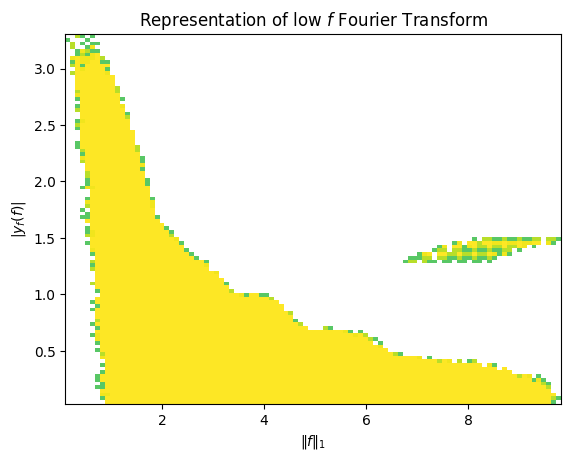

In [118]:
plt.hist2d(np.sum(np.abs(nf),axis=1),np.abs(nyf), bins=100,norm=colors.LogNorm(vmin=np.abs(nyf).min(), vmax=np.abs(nyf).max()))
plt.title("Representation of low $f$ Fourier Transform")
plt.xlabel("$\|f\|_1$")
plt.ylabel("$|y_f(f)|$")
plt.show()

Ignoring the artifact, we are still getting the full structure of the function. Maybe we even want to reduce the thereshold. Probably we are dominated still by lower frequency behavior.

In [119]:
bestinvft = []
for t in tlist:
    try:
        del calcinvdft
    except:
        print(" nothing to delete ")
    try:
        del cyc
    except:
        print(" nothing to delete ")
    try:
        del syc
    except:
        print(" nothing to delete ")  
    mempool.free_all_blocks()
    start = time.time()
    ycomp = np.prod([(np.pi*(fmax[i]-fmin[i]))/23 for i in range(6)])
    with cp.cuda.Device(0):
        ty = calcdft.process_inv(cp.asarray(nyf[np.abs(nyf)>t].reshape(-1,1)/ycomp),cp.asarray(nf[np.abs(nyf)>t,:]),0,2)
    end = time.time()
    print(" the time is ",end-start)
    print(" the threshold is ",t)
    with cp.cuda.Device(0):
        #print(ty[:20,:]/np.median(cp.asnumpy(ty))*np.median(y_mod_train))
        print(" the rms is ",rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))
        print(" the real rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).real,y_mod_train))
        print(" the imag rms is ",rmse((cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train)).imag,y_mod_train*0))
        print(" the imag rms is (no corr) ",rmse(cp.asnumpy(ty).imag,y_mod_train*0))
        bestinvft.append(rmse(cp.asnumpy(ty)/np.median(cp.asnumpy(ty))*np.median(y_mod_train),y_mod_train))

 nothing to delete 
 nothing to delete 
 nothing to delete 
 Diagnostics 
(1257, 6)
(6, 183813417)
[[ -9.695  -9.695  -9.695  -9.695]
 [-10.21  -10.21  -10.21  -10.21 ]
 [-10.15  -10.15  -10.15  -10.15 ]
 [-10.35  -10.35  -10.35  -10.35 ]
 [-10.78  -10.78  -10.78  -10.78 ]
 [-10.54   -9.65   -8.766  -7.875]]
[[-0.1869   0.2908  -0.1484  -0.094   -0.1714  -0.06036]
 [ 0.04218 -0.6523  -0.494    0.1732  -0.299    0.2815 ]
 [ 0.2607  -0.1763   0.7417  -0.3184   0.2208   0.08124]
 [ 0.8467  -0.0409  -0.313   -0.0992   0.2517  -0.07764]]
[[ 9.086  9.086  9.086  9.086]
 [ 9.555  9.555  9.555  9.555]
 [ 9.5    9.5    9.5    9.5  ]
 [ 9.695  9.695  9.695  9.695]
 [10.09  10.09  10.09  10.09 ]
 [ 7.203  8.09   8.98   9.87 ]]
[[-0.1456   -0.6147    0.002699  0.2451   -0.4407    0.1909  ]
 [-0.372    -0.4092   -0.02649   0.0593   -0.6587    0.1039  ]
 [ 0.1737   -0.3171   -0.4763    0.1456   -0.09186   0.1766  ]
 [ 0.455    -0.5195    0.4126   -0.0987   -0.2151   -0.3848  ]]
 Diagnostics 
[[ 3.80

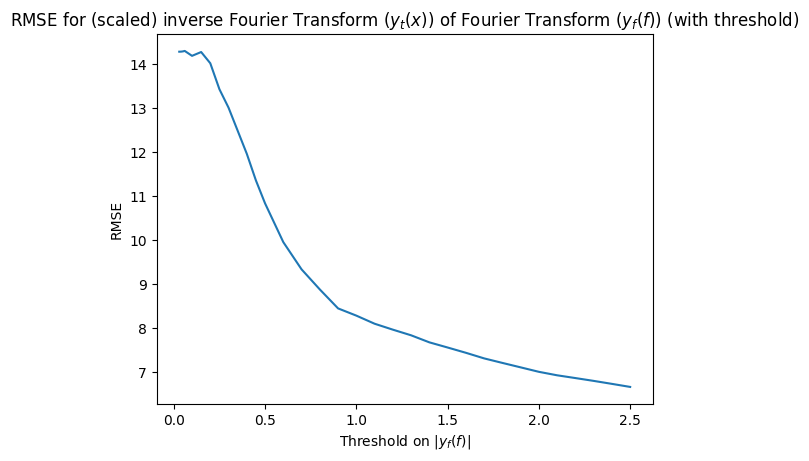

In [120]:
plt.plot(tlist,np.abs(bestinvft))
#plt.yscale('log')
plt.title("RMSE for (scaled) inverse Fourier Transform ($y_t(x)$) of Fourier Transform ($y_f(f)$) (with threshold)")
plt.ylabel("RMSE")
plt.xlabel("Threshold on $|y_f(f)|$")
plt.show()

Since I scale, I don't think I need to change the scale.

In [121]:
ycomp = np.prod([(np.pi*(fmax[i]-fmin[i])/8)/23 for i in range(6)])
print((nyf[np.abs(nyf)>0.31].reshape(-1,1)/ycomp).dtype)
print((nyf[np.abs(nyf)>0.31].reshape(-1,1)/ycomp).shape)
print(nf.dtype)
threshold = 1.4
pdf=bounds.E_pdf(np.abs(nyf[np.abs(nyf)>threshold].reshape(-1,1)/ycomp).astype('float64'),2*np.pi*((nf[np.abs(nyf)>threshold,:]).T).astype('float64'))

complex64
(19069416, 1)
float16


In [122]:
MM=18000
zv, tv, wv, sv = pdf.gen_ztw(MM)
wh, wn = bounds.nn_wnorm(wv)
print(wh.shape)
print(zv.shape)
print(sv.shape)
print(sv)

(6, 18000)
(18000,)
(18000,)
[-1.  1.  1. ... -1. -1. -1.]


In [141]:
model=gbnn.NeuralNet(num_features,MM)
print(model.params)
model.barron_init(num_features,(wh.T),(tv*zv).reshape(-1,1),((-1000)*(sv).reshape(-1,1).T/MM),np.array([[0]]))
print(model.params)

(array([[-0.26621202, -0.60209842, -0.35001861, -0.57601872, -0.15385881,
        -0.50651906],
       [-0.18999107,  0.35681959, -0.27095272,  0.59288024, -0.67998848,
        -0.13160103],
       [-0.3871228 , -0.5051906 , -0.46956293,  0.1450218 ,  0.43591808,
         0.14016223],
       ...,
       [ 0.30182159, -0.57802343,  0.45003543,  0.38350198, -0.13020409,
        -0.58088353],
       [-0.39146305, -0.27259772, -0.05574682, -0.48508817,  0.6106111 ,
         0.54401592],
       [-0.23700661, -0.45783862, -0.25784858,  0.30204434, -0.63340984,
        -0.4720665 ]]), array([[-0.78530499],
       [ 0.67129721],
       [-0.18472775],
       ...,
       [-0.0098125 ],
       [-0.17301634],
       [-0.28017559]]), array([[ 2.08243525e-05, -1.36526944e-05,  1.88067758e-06, ...,
        -2.23698733e-05, -4.53501208e-05,  2.79869707e-05]]), array([[0.]]))
(array([[-0.1123961 , -0.11914227,  0.01638357,  0.15383689,  0.30261414,
         0.29562703],
       [-0.10573436, -0.11208069

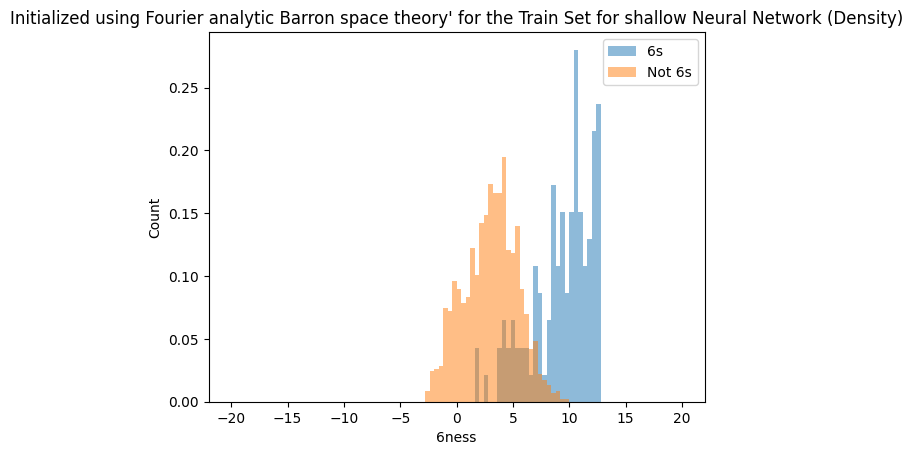

In [142]:
check_output, __ = model.forward_pass(X_train.T,model.params,'regression')
plt.hist(check_output[0][y_train>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_train<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [143]:
calculate_binary_metrics(check_output[0],y_train)

accuracy : 0.21241050119331742
precision : 0.10488245931283906
sensitivity or recall : 1.0


(116, 0, 151, 990)

In [123]:
class ShallowClassifierInit(nn.Module):
    def __init__(self, mean=0, max=1000):
        super(ShallowClassifierInit,self).__init__()
        self.fc1 = nn.Linear(num_features,MM)
        self.fc2 = nn.Linear(MM,1)     
        self.fc1.weight = torch.nn.Parameter(torch.Tensor(wh.T))
        self.fc1.bias = torch.nn.Parameter(torch.Tensor(tv*zv))      
        self.fc2.bias = torch.nn.Parameter(torch.Tensor(np.array([mean])))
        self.fc2.weight = torch.nn.Parameter(torch.Tensor((-max)*(sv).reshape(-1,1).T/MM))
      
        
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [124]:
model = ShallowClassifierInit()
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

(116, 1)
(1141, 1)
3.1637368
10.046555
tensor([[-1.8505,  4.8149,  4.1966,  ...,  6.2531,  1.4334,  4.2642]],
       grad_fn=<PermuteBackward0>)


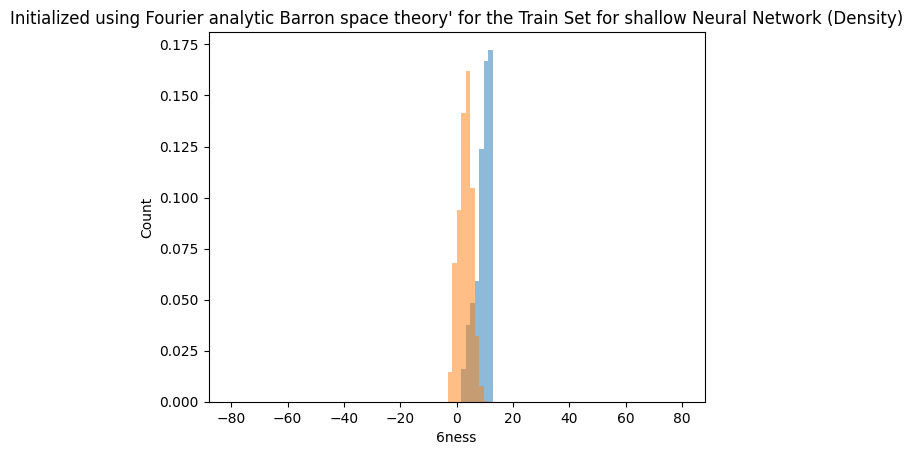

In [125]:
check_output = model(torch.Tensor(X_train))
print(check_output.detach().cpu().numpy()[y_train>.5].shape)
print(check_output.detach().cpu().numpy()[y_train<.5].shape)
print(np.median(check_output.detach().cpu().numpy()[y_train<.5]))
print(np.median(check_output.detach().cpu().numpy()[y_train>.5]))
print(check_output.T)
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [126]:
model = ShallowClassifierInit(mean=-np.median(check_output.detach().cpu().numpy()[y_train<.5])/2-np.median(check_output.detach().cpu().numpy()[y_train>.5])/2)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.FloatTensor ([9.0]))
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001, momentum=0.9)

In [144]:
model.barron_init(num_features,(wh.T),(tv*zv).reshape(-1,1),((-1000)*(sv).reshape(-1,1).T/MM),np.array([[-np.median(check_output[0][y_train<.5])/2-np.median(check_output[0][y_train>.5])/2]]))

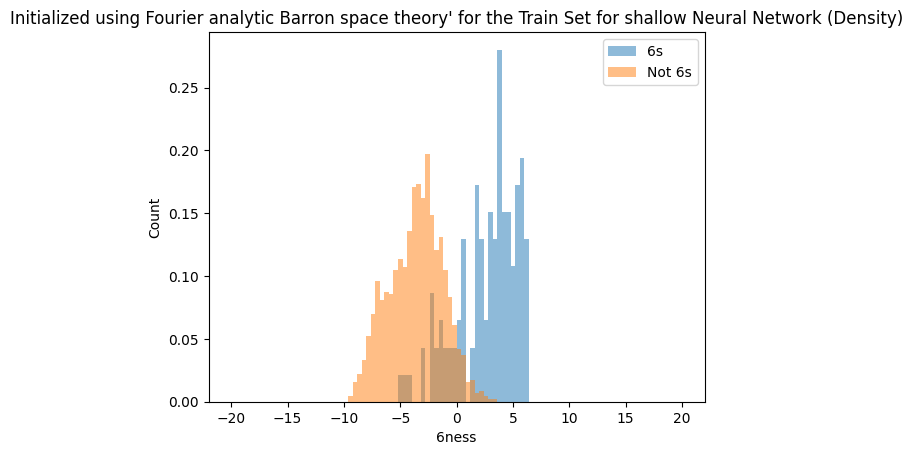

In [145]:
check_output, __ = model.forward_pass(X_train.T,model.params,'regression')
plt.hist(check_output[0][y_train>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_train<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [146]:
calculate_binary_metrics(check_output[0],y_train)

accuracy : 0.9347653142402546
precision : 0.6075949367088608
sensitivity or recall : 0.8275862068965517


(96, 20, 1079, 62)

In [ ]:
check_output = model(torch.Tensor(X_train))
plt.hist(check_output.detach().cpu().numpy()[y_train>.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.hist(check_output.detach().cpu().numpy()[y_train<.5],alpha = 0.5,bins=100,density=True,range=(-80,80))
plt.title("Initialized using Fourier analytic Barron space theory' for the Train Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
calculate_binary_metrics(check_output.detach().cpu().numpy(),y_train)

With our better representation, we can improve our threshold and our sensitivity, also, due to using this initialization, we end up being able to have a lot more nodes than we might feel comfortable with in a standard case.

In [ ]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density) after training.")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

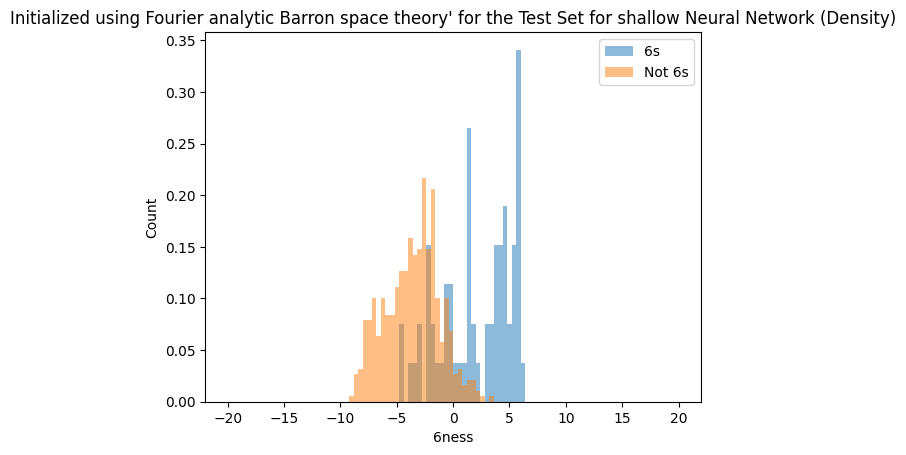

In [148]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density)")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [149]:
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.9148148148148149
precision : 0.6388888888888888
sensitivity or recall : 0.696969696969697


(46, 20, 448, 26)

In [ ]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

In [150]:
train_loss = []
test_loss = []
for epoch in range(200):
    costs = model.train(X_train.T, y_train.reshape(-1,1).T, epoch_num=1, batch_size=64,cost_fun='cross_entropy',lambd=0.01)
    train_loss.append(costs[0])
    check_output, __ = model.forward_pass(X_test.T,model.params,'cross_entropy')
    costs = gbnn.NeuralNet.cost(y_test.reshape(-1,1).T, check_output[0], "cross_entropy")
    test_loss.append(costs)

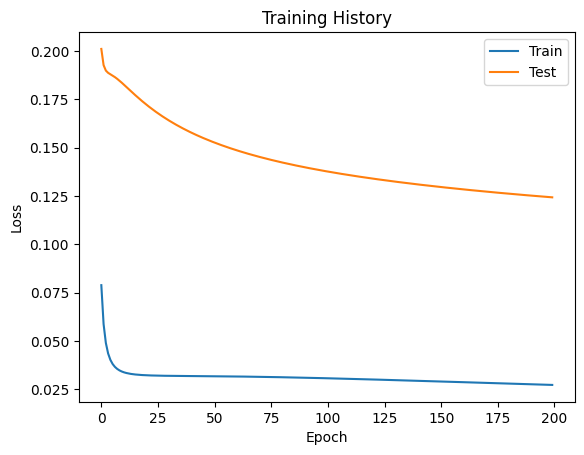

In [151]:
plt.plot(range(200),train_loss)
plt.plot(range(200),test_loss)
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
history = train_model(model,90)

print('Finished Training')

In [ ]:
plt.plot(np.asarray(history['loss']).T[0],np.asarray(history['loss']).T[1])
plt.plot(np.asarray(history['test']).T[0],np.asarray(history['test']).T[1])
plt.legend(['Train', 'Test'])
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
check_output = model(torch.Tensor(X_test))
plt.hist(check_output.detach().cpu().numpy()[y_test>.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.hist(check_output.detach().cpu().numpy()[y_test<.5],alpha = 0.5,bins=100,density=True,range=(-40,40))
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density) after training.")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

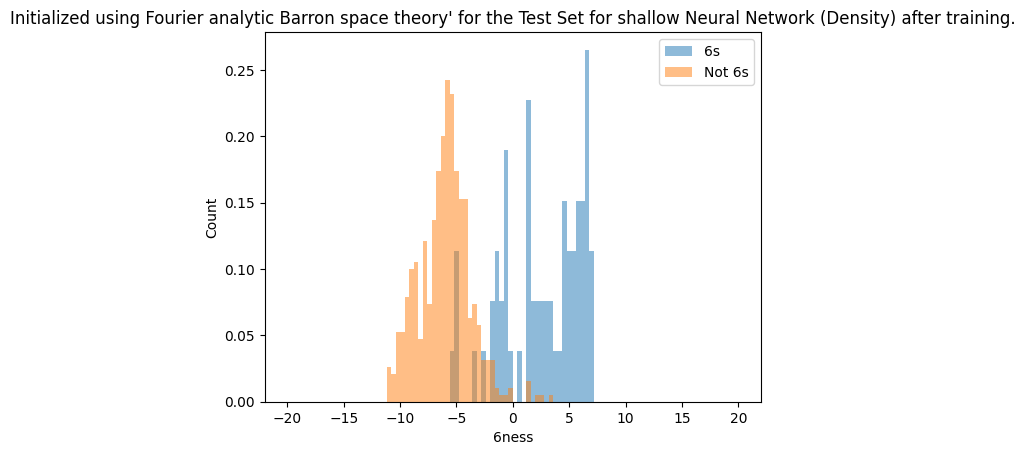

In [152]:
check_output, __ = model.forward_pass(X_test.T,model.params,'regression')
plt.hist(check_output[0][y_test>.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.hist(check_output[0][y_test<.5],alpha = 0.5,bins=100,density=True,range=(-20,20))
plt.legend(['6s', 'Not 6s'])
plt.title("Initialized using Fourier analytic Barron space theory' for the Test Set for shallow Neural Network (Density) after training.")
plt.xlabel("6ness")
plt.ylabel("Count")
plt.show()

In [ ]:
loss = criterion(check_output, torch.Tensor(y_test).reshape((-1, 1)))
print(loss)

In [153]:
calculate_binary_metrics(check_output[0],y_test)

accuracy : 0.9537037037037037
precision : 0.8867924528301887
sensitivity or recall : 0.7121212121212122


(47, 19, 468, 6)

To really improve these results we should introduce early stop or some similar regularization. But it is clear that we can continue to use this technique to improve the starting initialization. One of the problems with training a neural network is that the network finds itself in a minimum where it does not generalize well. Here we are starting close to the minimum and in the limit might not need any training at all. We are also able to have many more parameters than we otherwise would be able to have.